# BEE 4750 Homework 1: Introduction to Using Julia

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE 4750/bee4750-hw1-pdc76`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [3]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [4]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [ ]:
function minimum(array)
    # initialize the minimum value counter
    min_value = 0
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

**Solution to Problem 1.1**

The issue with the original code is that the value, 0, held by the variable, "min_value," was less than the minimum value in the array, "array_values." To address this, I initialized the min_value variable to be 1/0, which Julia interprets to be infinity. This guarantees that any value in the list will be less than or equal to the originally initialized minimum value. Therefore, the function "minimum" will always return the correct value minimum value of an array. The corrected code is below.

In [ ]:
function minimum(array)
    # initialize the minimum value counter
    min_value = 1/0
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);


#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [ ]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(student_grades)
  return average_grade
end

@show average_grade;

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

**Problem 1.2 Solution**

UndefVarError indicates an issue with global and local variables within a function. Since "average_grade" is only defined within the function, "class_average," you cannot show "average_grade" without defining it in the global space. To correct this, you must define "average_grade" by calling "class_average" with the array "student_grades." The corrected code is below:

In [ ]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(student_grades)
  return average_grade
end

average_grade = class_average(student_grades)
@show average_grade;



#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [3]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zero(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

MethodError: MethodError: no method matching setindex!(::Int64, ::Bool, ::Int64)
The function `setindex!` exists, but no method is defined for this combination of argument types.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

**Problem 1.3 Solution**

A MethodError is an error where a function is passed an argument that it cannot handle or recognize. This occurs in 1.3 when the variable outcomes is created by calling the function zero(). It is passed an argument that is an integer, which is correct, but the output of this is a single integer, 0. 0[i] is not valid syntax, so outcomes[i] throws a method error. To fix this, we use the function zeros() which creates an array of zeros with length of the integer argument. See corrected code below:

In [4]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.369


#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [5]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect - m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

MethodError: MethodError: no method matching -(::Vector{Float64}, ::Float64)
For element-wise subtraction, use broadcasting with dot syntax: array .- scalar
The function `-` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  -(!Matched::Complex{Bool}, ::Real)
   @ Base complex.jl:329
  -(!Matched::Missing, ::Number)
   @ Base missing.jl:123
  -(!Matched::BigFloat, ::Union{Float16, Float32, Float64})
   @ Base mpfr.jl:565
  ...


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

**Problem 1.4 Solution**

This MethodError indicates that we are trying to do element-wise subtraction, but what we are subtracting is not an array. This occurs in the remove_mean([]) function when we try to subtract vect - m. Julia doesn't know how to deal with subtraction of an integer from an array, so we have to use the operator ".-" in order to handle this. See corrected code below:

In [7]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [-0.3742068799795504, -0.22137438001670173, 0.13983318238138076, 0.17615354307930053, 0.1770106929061267, -0.4024537712628796, -0.00543377164007619, -0.45454765208074355, -0.19388551551759303, -0.2831164582780967, 0.07666696864044309, 0.17880756616487137, 0.2178993486155042, 0.0991907535328822, -0.4152502813992106, -0.06127153992086676, 0.04674876957855445, 0.08371659587385427, 0.03007195672498475, -0.2069888916686049, 0.252100858986954, 0.37843109447395307, -0.4574853175924074, -0.4218628542613888, 0.17477359828416805, 0.42552388772810135, 0.17960282225387292, 0.08171705328587808, -0.3314568362514504, 0.4771438754559272, 0.11448114243902796, -0.1681954369520654, 0.2058155511074622, 0.44341714762039874, 0.4457723321227772, -0.27701365434692904, 0.4750493099029566, 0.2716390915822544, -0.03140445133211622, 0.39079768314006547, 0.44822514451307005, -0.052477620973906625, 0.4551769023545912, -0.488942033179973, 0.47208558686412117, 0.41831611024973325, 0.4575425

1000-element Vector{Float64}:
 -0.3742068799795504
 -0.22137438001670173
  0.13983318238138076
  0.17615354307930053
  0.1770106929061267
 -0.4024537712628796
 -0.00543377164007619
 -0.45454765208074355
 -0.19388551551759303
 -0.2831164582780967
  ⋮
 -0.1542603211615855
 -0.2502250217142279
  0.22997610173145833
 -0.002288954204928473
 -0.014550916429255989
  0.12551199798981827
  0.3772353827400948
  0.05815824435508066
 -0.08918753570927829

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

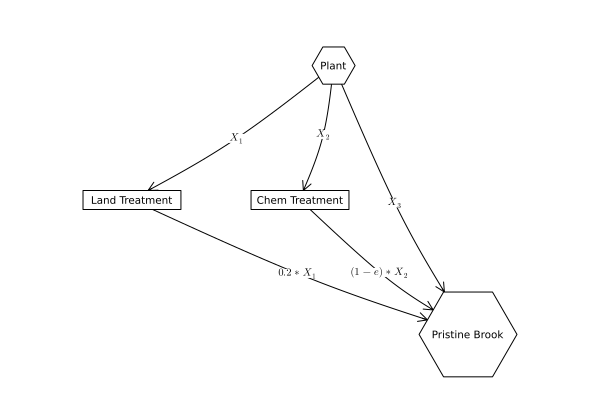

In [19]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"X_1", (1,3) => L"X_2", (1, 4) => L"X_3",(2, 4) => L"0.2*X_1",(3, 4) => L"(1-e)*X_2")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

**Problem 2 Graph Explanation**

The graph shows that the initial plant output, X, is subdivided into 3 parts: $X_1$, $X_2$, $X_3$. $X_1$ refers to the effluent that recieves land treatment, $X_2$ is the chemically treated outflow, and $X_3$ is the effluent that runs directly into the stream. Land treatment removes 80% of the YUK so the effluent from the land to the stream is $0.2$ $X_1$. The chemical treatment removes $(1-e)$ $X_2$ YUK, where $e$ is the efficiency and $e$ $=$ ($1$ $-$ $0.005$ $*$ $X_2$). This means that $(1-e)$ $X_2$ YUK runs into the stream from the chemical treatment plant.

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).


**Problem 2.1 Solution**

These are the given and maximum values for the effluent, YUK concentration, and mass flow rate. While $C$ $=$ $1$ $kg/day$, I think it is important to include this value in my equations, as it the most complete equation and would make for more simple changes to have a singular global variable, $C$.
\begin{align*}
& X = 100 \;\; \text{m}^3/\text{day} \\[6pt]
& C = 1 \;\; \text{kg}/\text{m}^3 \;\; \text{of YUK} \\[6pt]
& \dot{m} = 100 \;\; \text{kg}/\text{day} \\[6pt]
& \dot{m}_{\max} = 20 \;\; \text{kg}/\text{day} \\[12pt]
\end{align*}

This is the given collective volumetric flow rate for all 3 effluent discharges, with $X_3$ being solved for as the difference between the total and the two reduction methods. 
\begin{align*}
& X = X_1 + X_2 + X_3 \quad \Rightarrow \quad X_3 = X - X_1 - X_2 \\[12pt]
\end{align*}

$\dot{m}_1$ and $\dot{m}_2$ represent the mass flow rate of each treated effluent stream, and $\dot{m}_3$ is the untreated effluent.
\begin{align*}
& \dot{m}_1 = 0.2 X_1 C \\[6pt]
& \dot{m}_2 = (1-e) X_2 C \\[6pt]
& \quad = \big(1 - (1 - 0.005X_2)\big) X_2 C \\[6pt]
& \dot{m}_3 = X_3 C \\[12pt]
\end{align*}

These equations of total mass flow rate and total mass flow rate effluent. The maximum total mass flow is the total effluent allowed in the stream, $\dot{m}_{\max} = 20$.
\begin{align*}
& \dot{m}_{\text{tot}} = \dot{m}_1 + \dot{m}_2 + \dot{m}_3 \\[6pt]
& \dot{m}_{\text{tot}} \leq \dot{m}_{\max} \\[12pt]
\end{align*}

This is the cost equation. The goal is to minimize this value while staying under the $\dot{m}_{\max} = 20$ maximum.
\begin{align*}
& \text{Cost} = \frac{X_1^2}{20} + 1.50 X_2
\end{align*}



#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [23]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [ ]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]


Make sure you comment your code appropriately to make it clear what is
going on and why.

**Problem 2.2 Solution Code**

In [ ]:
function yuk_treatment_method(x1,x2)
    #Intial Givens
    c = 1
    x = 100
    mdot_max = 20
    
    #Calculate the effluent volume directly into stream
    x3 = x - x1 - x2
    
    #Solve for mass flow rate of each effluent and find sum of effluent into the stream
    mdot1 = x1 * c * 0.2
    mdot2 = (1-(1-0.005*x2)) * (x2 * c)
    mdot3 = x3 * c
    mdot_tot = mdot1 + mdot2 + mdot3

    #Calculate the cost of the chosen treatment plan
    cost = ((x1^2)/20) + (1.5*x2)
    
    #return the total YUK in the stream and the cost of the treatment
    return (mdot_tot,cost)
end


eff = 54.5
cost = 80.0


The function "yuk_treatment_method(x1,x2)" takes 2 parameters, x1 and x2, which are used to calculate the total effluent entering stream, as well as the proportion that recieves land and chemical treatment. It also calculates the cost associated with each set of the chosen proportions entered as function arguments.


#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

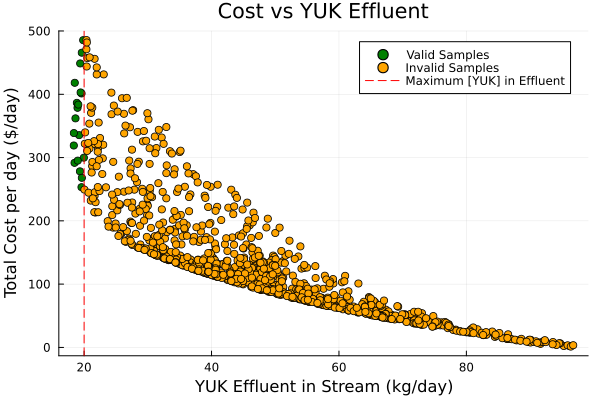

In [98]:
#Define the number of samples and total volumetric flow rate
N = 1000
X = 100 #m^3/day

#Take a Dirilecht sample and store it in a 3xN matrix
dir = Dirichlet(3,1)
sample = rand(dir,N)

#Define the vectors for X1 and X2
x1 = X .* vec(sample[1,:])
x2 = X .* vec(sample[2,:])

#Broadcast samples over the function using method shown above
output = yuk_treatment_method.(x1,x2)
eff = [out[1] for out in output]
cost = [out[2] for out in output]

#Define lists for viable and non-viable effluent treatment means
viable = []
nviable = []

#Iterate through all of the samples check to see if each distribution of x1 and x2 is a viable 
#combination by making sure the effluent is below 20 kg/day and assigning it to a list accordingly.
for i in eachindex(x1,x2,eff,cost)
    if eff[i] <= 20
        push!(viable,(x1[i],x2[i],eff[i],cost[i]))
    else
        push!(nviable,(x1[i],x2[i],eff[i],cost[i]))
    end
end

#Define the effluent and cost for valid and invalid samples (X<20 kg/day) and seperate for ease of plotting
eff_viable = [out[3] for out in viable]
cost_viable = [out[4] for out in viable]
eff_nviable = [out[3] for out in nviable]
cost_nviable = [out[4] for out in nviable]

#Plot each data set, a vertical line showing the cutoff threshold, and min/max of cost and effluent
plt = scatter(eff_viable, cost_viable, color=:green, label = "Valid Samples", xlabel="YUK Effluent in Stream (kg/day)", 
    ylabel="Total Cost per day (\$/day)", title="Cost vs YUK Effluent")

scatter!(eff_nviable, cost_nviable, color=:orange, label = "Invalid Samples", xlabel="YUK Effluent in Stream (kg/day)", 
    ylabel="Total Cost per day (\$/day)", title="Cost vs YUK Effluent")

vline!(plt, [20]; linestyle=:dash, color=:red, label="Maximum [YUK] in Effluent")






#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

**Problem 2.3/2.4 Answers**

## References

List any external references consulted, including classmates.